# Air Quality in India- Data Visualization EDA Project

As rapid urbanization reshapes global landscapes, air pollution stands as a critical threat to public health and ecological sustainability. This project investigates air quality data across major Indian cities to unpack complex environmental patterns. Through systematic preprocessing and intuitive data visualizations, we map Air Quality Index (AQI) distributions, isolate key pollutant drivers, and highlight the most severely affected regions.

<img src='https://img.smartertravel.com/production/Articles/India%20Travel%20Guide%20What%20to%20Do%20in%20India/Feature/large_India_Travel_Guide_What_to_Do_in_India_feature_image_1e6b5d0bd0.webp' width='750'>

In [1]:
# Libraries
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns


import datetime as dt


import warnings
warnings.filterwarnings("ignore")
plt.style.use("fivethirtyeight")
plt.rcParams["figure.figsize"] = (12, 6)

# EDA

In [2]:
import kagglehub

# Download latest version
path = kagglehub.dataset_download("rohanrao/air-quality-data-in-india")

print("Path to dataset files:", path)

Path to dataset files: C:\Users\furka\.cache\kagglehub\datasets\rohanrao\air-quality-data-in-india\versions\12


In [3]:
df = pd.read_csv(r"C:\Users\furka\.cache\kagglehub\datasets\rohanrao\air-quality-data-in-india\versions\12\city_day.csv")

In [4]:
df.head()

,City,Date,PM2.5,PM10,NO,NO2,NOx,NH3,CO,SO2,O3,Benzene,Toluene,Xylene,AQI,AQI_Bucket
0,Ahmedabad,2015-01-01,NaN,NaN,0.92,18.22,17.15,NaN,0.92,27.64,133.36,0.00,0.02,0.00,NaN,NaN
1,Ahmedabad,2015-01-02,NaN,NaN,0.97,15.69,16.46,NaN,0.97,24.55,34.06,3.68,5.50,3.77,NaN,NaN
2,Ahmedabad,2015-01-03,NaN,NaN,17.40,19.30,29.70,NaN,17.40,29.07,30.70,6.80,16.40,2.25,NaN,NaN
3,Ahmedabad,2015-01-04,NaN,NaN,1.70,18.48,17.97,NaN,1.70,18.59,36.08,4.43,10.14,1.00,NaN,NaN
4,Ahmedabad,2015-01-05,NaN,NaN,22.10,21.42,37.76,NaN,22.10,39.33,39.31,7.01,18.89,2.78,NaN,NaN


In [5]:
df.tail()

,City,Date,PM2.5,PM10,NO,NO2,NOx,NH3,CO,SO2,O3,Benzene,Toluene,Xylene,AQI,AQI_Bucket
29526,Visakhapatnam,2020-06-27,15.02,50.94,7.68,25.06,19.54,12.47,0.47,8.55,23.30,2.24,12.07,0.73,41.0,Good
29527,Visakhapatnam,2020-06-28,24.38,74.09,3.42,26.06,16.53,11.99,0.52,12.72,30.14,0.74,2.21,0.38,70.0,Satisfactory
29528,Visakhapatnam,2020-06-29,22.91,65.73,3.45,29.53,18.33,10.71,0.48,8.42,30.96,0.01,0.01,0.00,68.0,Satisfactory
29529,Visakhapatnam,2020-06-30,16.64,49.97,4.05,29.26,18.80,10.03,0.52,9.84,28.30,0.00,0.00,0.00,54.0,Satisfactory
29530,Visakhapatnam,2020-07-01,15.00,66.00,0.40,26.85,14.05,5.20,0.59,2.10,17.05,NaN,NaN,NaN,50.0,Good


In [6]:
df.shape

(29531, 16)

In [7]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 29531 entries, 0 to 29530
Data columns (total 16 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   City        29531 non-null  object 
 1   Date        29531 non-null  object 
 2   PM2.5       24933 non-null  float64
 3   PM10        18391 non-null  float64
 4   NO          25949 non-null  float64
 5   NO2         25946 non-null  float64
 6   NOx         25346 non-null  float64
 7   NH3         19203 non-null  float64
 8   CO          27472 non-null  float64
 9   SO2         25677 non-null  float64
 10  O3          25509 non-null  float64
 11  Benzene     23908 non-null  float64
 12  Toluene     21490 non-null  float64
 13  Xylene      11422 non-null  float64
 14  AQI         24850 non-null  float64
 15  AQI_Bucket  24850 non-null  object 
dtypes: float64(13), object(3)
memory usage: 3.6+ MB


In [8]:
df.isnull().sum()

City              0
Date              0
PM2.5          4598
PM10          11140
NO             3582
NO2            3585
NOx            4185
NH3           10328
CO             2059
SO2            3854
O3             4022
Benzene        5623
Toluene        8041
Xylene        18109
AQI            4681
AQI_Bucket     4681
dtype: int64

In [9]:
df.describe()

,PM2.5,PM10,NO,NO2,NOx,NH3,CO,SO2,O3,Benzene,Toluene,Xylene,AQI
count,24933.000000,18391.000000,25949.000000,25946.000000,25346.000000,19203.000000,27472.000000,25677.000000,25509.000000,23908.000000,21490.000000,11422.000000,24850.000000
mean,67.450578,118.127103,17.574730,28.560659,32.309123,23.483476,2.248598,14.531977,34.491430,3.280840,8.700972,3.070128,166.463581
std,64.661449,90.605110,22.785846,24.474746,31.646011,25.684275,6.962884,18.133775,21.694928,15.811136,19.969164,6.323247,140.696585
min,0.040000,0.010000,0.020000,0.010000,0.000000,0.010000,0.000000,0.010000,0.010000,0.000000,0.000000,0.000000,13.000000
25%,28.820000,56.255000,5.630000,11.750000,12.820000,8.580000,0.510000,5.670000,18.860000,0.120000,0.600000,0.140000,81.000000
50%,48.570000,95.680000,9.890000,21.690000,23.520000,15.850000,0.890000,9.160000,30.840000,1.070000,2.970000,0.980000,118.000000
75%,80.590000,149.745000,19.950000,37.620000,40.127500,30.020000,1.450000,15.220000,45.570000,3.080000,9.150000,3.350000,208.000000
max,949.990000,1000.000000,390.680000,362.210000,467.630000,352.890000,175.810000,193.860000,257.730000,455.030000,454.850000,170.370000,2049.000000


In [10]:
df.corr(numeric_only=True)

,PM2.5,PM10,NO,NO2,NOx,NH3,CO,SO2,O3,Benzene,Toluene,Xylene,AQI
PM2.5,1.000000,0.846498,0.433491,0.350709,0.436792,0.275086,0.089912,0.132325,0.161238,0.023911,0.117080,0.114579,0.659181
PM10,0.846498,1.000000,0.502349,0.464380,0.527768,0.376816,0.112588,0.256974,0.244919,0.022265,0.169335,0.081700,0.803313
NO,0.433491,0.502349,1.000000,0.478070,0.794890,0.185621,0.212607,0.170322,0.014580,0.035771,0.150857,0.094237,0.452191
NO2,0.350709,0.464380,0.478070,1.000000,0.627627,0.234938,0.356521,0.392233,0.293349,0.025260,0.273926,0.171701,0.537071
NOx,0.436792,0.527768,0.794890,0.627627,1.000000,0.166224,0.226992,0.238397,0.093170,0.039121,0.189386,0.087398,0.486450
NH3,0.275086,0.376816,0.185621,0.234938,0.166224,1.000000,0.104891,-0.038998,0.094972,-0.015650,0.013227,-0.019813,0.252019
CO,0.089912,0.112588,0.212607,0.356521,0.226992,0.104891,1.000000,0.489697,0.041736,0.061861,0.277904,0.154889,0.683346
SO2,0.132325,0.256974,0.170322,0.392233,0.238397,-0.038998,0.489697,1.000000,0.162142,0.036110,0.296139,0.251195,0.490586
O3,0.161238,0.244919,0.014580,0.293349,0.093170,0.094972,0.041736,0.162142,1.000000,0.020255,0.130209,0.111410,0.198991
Benzene,0.023911,0.022265,0.035771,0.025260,0.039121,-0.015650,0.061861,0.036110,0.020255,1.000000,0.739286,0.415427,0.044407


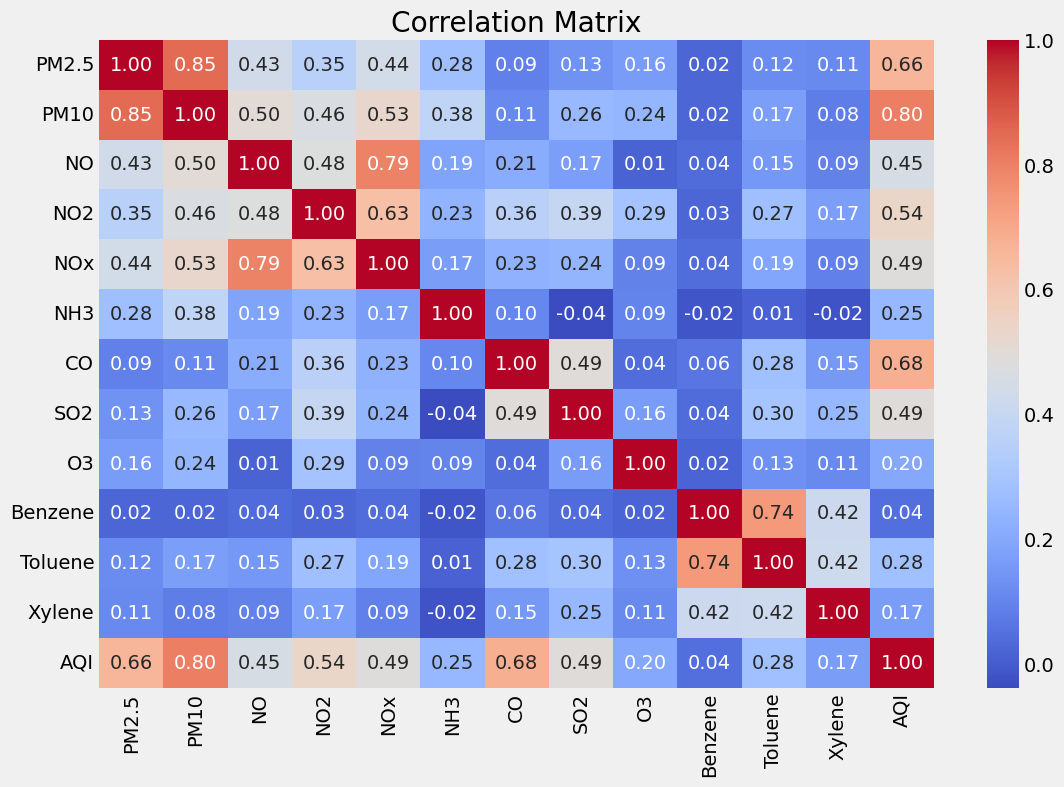

In [11]:
# Heatmap 
plt.figure(figsize=(12, 8))
sns.heatmap(df.corr(numeric_only=True), annot=True, fmt=".2f", cmap='coolwarm')      
plt.title("Correlation Matrix")      
plt.show()

In [12]:
df["Date"] = pd.to_datetime(df["Date"])

In [13]:
cols = ['PM2.5', 'PM10', 'NO', 'NO2', 'NOx', 'NH3', 'CO', 'SO2', 'O3', 'Benzene', 'Toluene', 'Xylene','AQI']

df[cols] = df[cols].fillna(df[cols].mean().round(2))

In [14]:
df['AQI_Bucket'].value_counts()

AQI_Bucket
Moderate        8829
Satisfactory    8224
Poor            2781
Very Poor       2337
Good            1341
Severe          1338
Name: count, dtype: int64

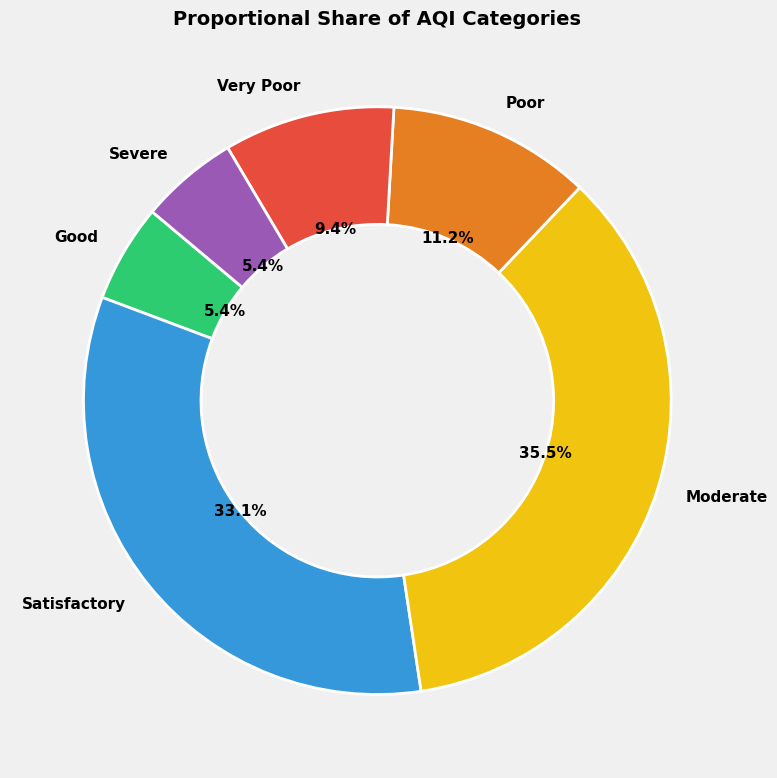

In [15]:
# AQI order and color palette
aqi_order = ['Good', 'Satisfactory', 'Moderate', 'Poor', 'Very Poor', 'Severe']
colors = ['#2ecc71', '#3498db', '#f1c40f', '#e67e22', '#e74c3c', '#9b59b6']

counts = df['AQI_Bucket'].value_counts().reindex(aqi_order).dropna()

plt.figure(figsize=(8, 8))
plt.pie(
    counts, 
    labels=counts.index, 
    autopct='%1.1f%%', 
    startangle=140, 
    colors=colors, 
    wedgeprops=dict(width=0.4, edgecolor='white', linewidth=2), # Donut style
    textprops={'fontsize': 11, 'weight': 'bold'}
)

plt.title('Proportional Share of AQI Categories', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

In [16]:
bins = [0,50,100,200,300,400,500]
labels = [
    "Good",
    "Satisfactory",
    "Moderate",
    "Poor",
    "Very Poor",
    "Severe"
]

df["AQI_Bucket"] = df["AQI_Bucket"].fillna(
    pd.cut(df["AQI"], bins=bins, labels=labels)
)

In [17]:
aqi_map = {
    "Good": 1,
    "Satisfactory": 2,
    "Moderate": 3,
    "Poor": 4,
    "Very Poor": 5,
    "Severe": 6
}

df["AQI_Level"] = df["AQI_Bucket"].map(aqi_map)

In [18]:
df.isnull().sum()

City          0
Date          0
PM2.5         0
PM10          0
NO            0
NO2           0
NOx           0
NH3           0
CO            0
SO2           0
O3            0
Benzene       0
Toluene       0
Xylene        0
AQI           0
AQI_Bucket    0
AQI_Level     0
dtype: int64

In [19]:
df["Year"] = df["Date"].dt.year
df["Month"] = df["Date"].dt.month
df["Day"] = df["Date"].dt.day

In [20]:
df["Month"].value_counts()

Month
5     2821
6     2811
3     2749
4     2702
1     2621
2     2457
12    2362
10    2263
11    2201
7     2196
8     2175
9     2173
Name: count, dtype: int64

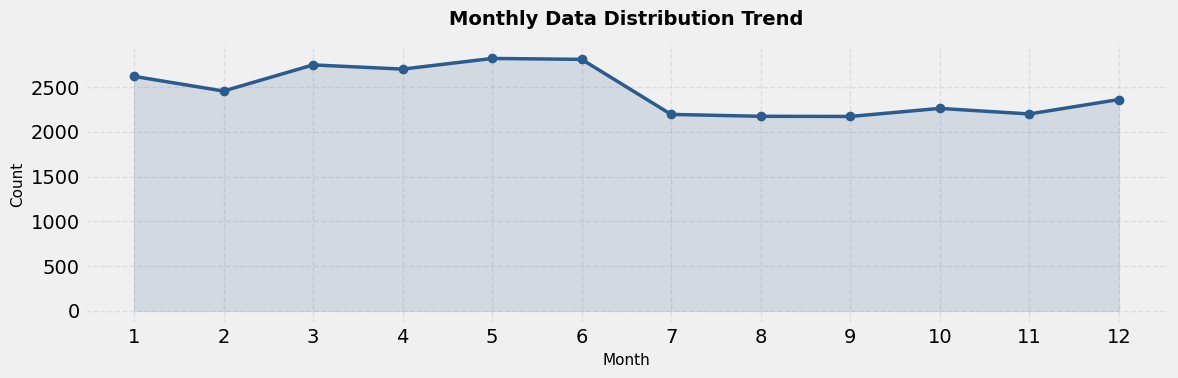

In [21]:
import matplotlib.pyplot as plt

month_counts = df['Month'].value_counts().sort_index()

plt.figure(figsize=(12, 4))
plt.plot(month_counts.index.astype(str), month_counts.values, marker='o', linewidth=2.5, color='#2b5c8f')
plt.fill_between(month_counts.index.astype(str), month_counts.values, alpha=0.15, color='#2b5c8f')

plt.title('Monthly Data Distribution Trend', fontsize=14, fontweight='bold', pad=15)
plt.xlabel('Month', fontsize=11)
plt.ylabel('Count', fontsize=11)
plt.grid(True, linestyle='--', alpha=0.5)
sns.despine()
plt.tight_layout()
plt.show()

In [22]:
season_map = {
    12:"Winter", 1:"Winter", 2:"Winter",
    3:"Summer", 4:"Summer", 5:"Summer",
    6:"Monsoon", 7:"Monsoon", 8:"Monsoon", 9:"Monsoon",
    10:"Post-Monsoon", 11:"Post-Monsoon"
}

df["Season"] = df["Month"].map(season_map)

In [23]:
df[["Month","Season"]].sample(10)

,Month,Season
20257,2,Winter
10368,5,Summer
18072,4,Summer
4413,4,Summer
16022,12,Winter
28514,9,Monsoon
28741,5,Summer
7551,9,Monsoon
10158,4,Summer
94,4,Summer


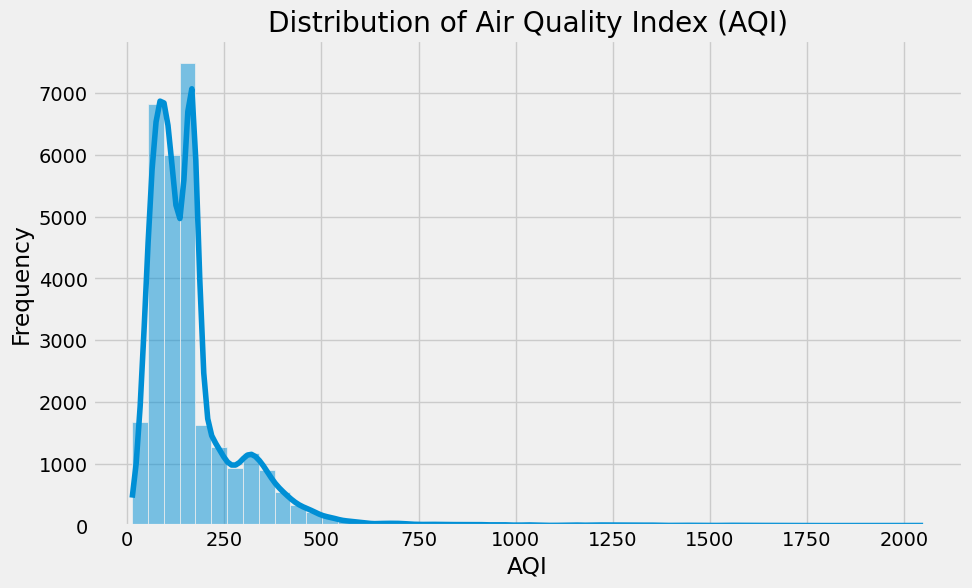

In [24]:
plt.figure(figsize=(10,6))

sns.histplot(df["AQI"], bins=50, kde=True)

plt.title("Distribution of Air Quality Index (AQI)")
plt.xlabel("AQI")
plt.ylabel("Frequency")

plt.show()

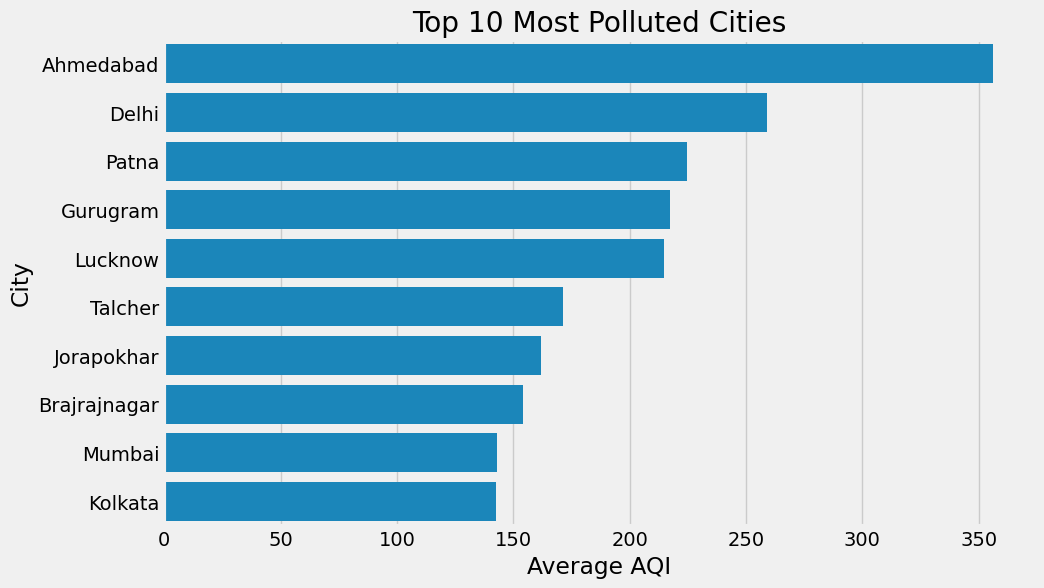

In [25]:
top_cities = df.groupby("City")["AQI"].mean().sort_values(ascending=False).head(10)

plt.figure(figsize=(10,6))

sns.barplot(x=top_cities.values, y=top_cities.index)

plt.title("Top 10 Most Polluted Cities")
plt.xlabel("Average AQI")
plt.ylabel("City")

plt.show()

Text(0.5, 1.0, 'Pollutant Correlation Matrix')

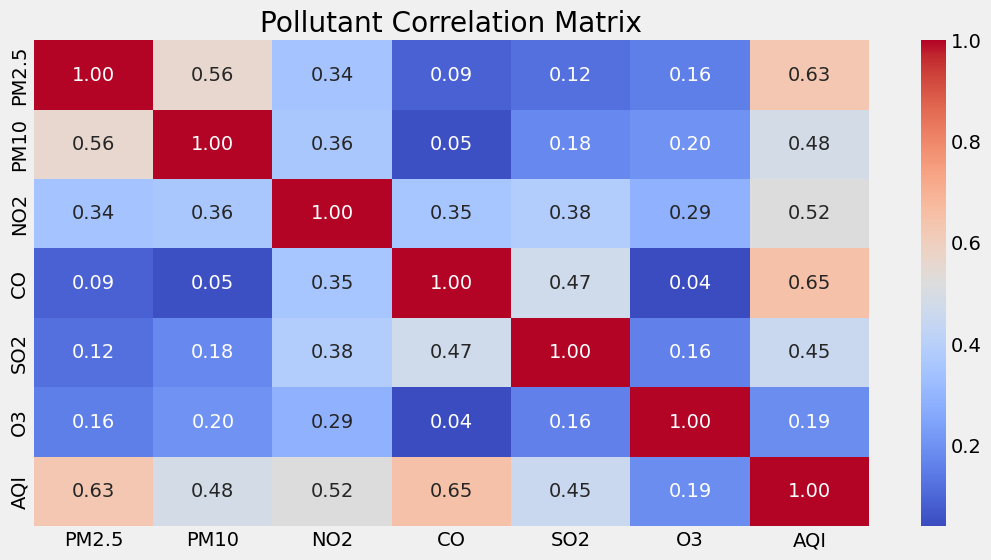

In [26]:
pollutants = ['PM2.5', 'PM10', 'NO2', 'CO', 'SO2', 'O3', 'AQI']
sns.heatmap(df[pollutants].corr(), annot=True, cmap="coolwarm", fmt=".2f")
plt.title("Pollutant Correlation Matrix")

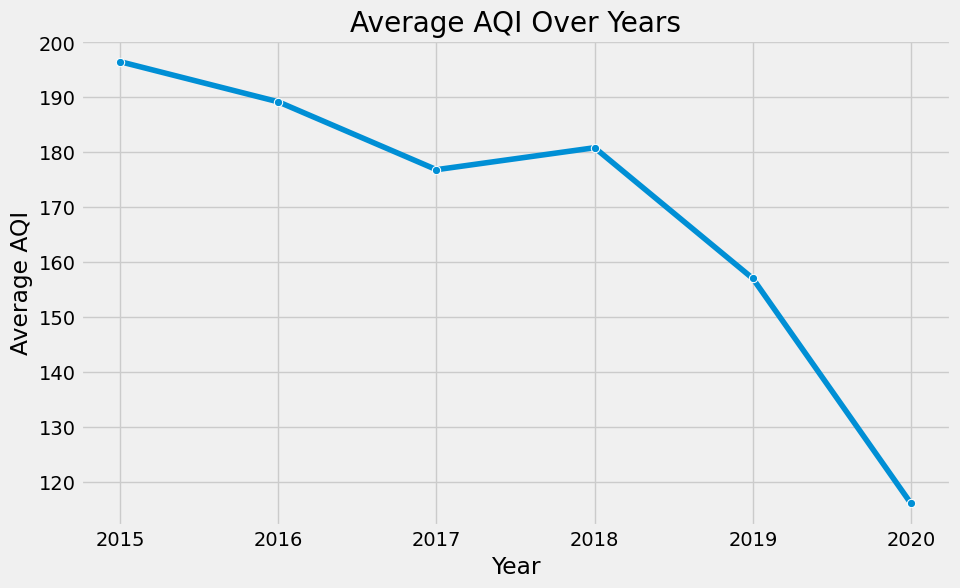

In [27]:
yearly_pollution = df.groupby("Year")["AQI"].mean()

plt.figure(figsize=(10,6))

sns.lineplot(x=yearly_pollution.index, y=yearly_pollution.values, marker="o")

plt.title("Average AQI Over Years")
plt.xlabel("Year")
plt.ylabel("Average AQI")

plt.show()

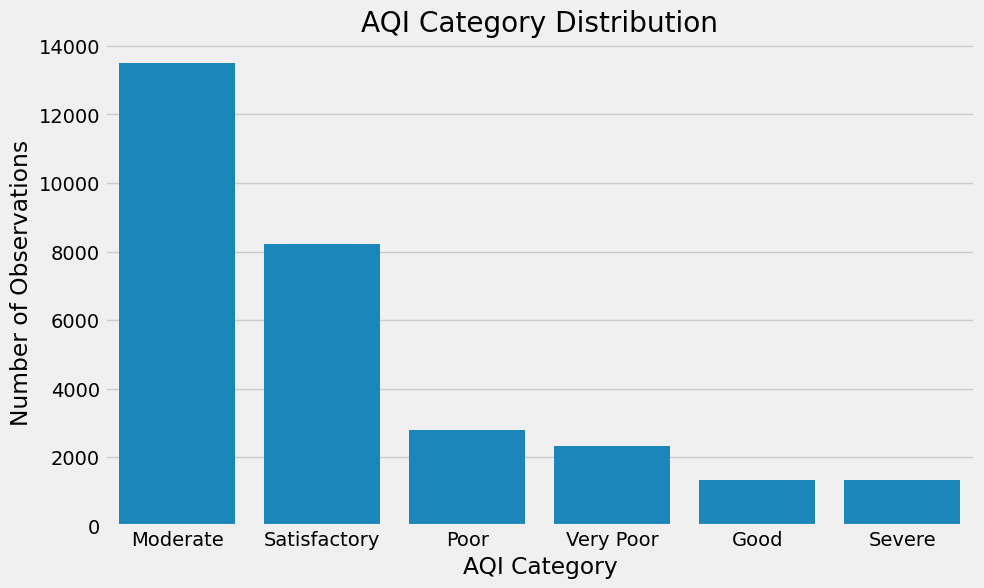

In [28]:
plt.figure(figsize=(10,6))

sns.countplot(x="AQI_Bucket", data=df, order=df["AQI_Bucket"].value_counts().index)

plt.title("AQI Category Distribution")
plt.xlabel("AQI Category")
plt.ylabel("Number of Observations")

plt.show()

<Axes: title={'center': 'Top 10 Cleanest Cities'}, ylabel='City'>

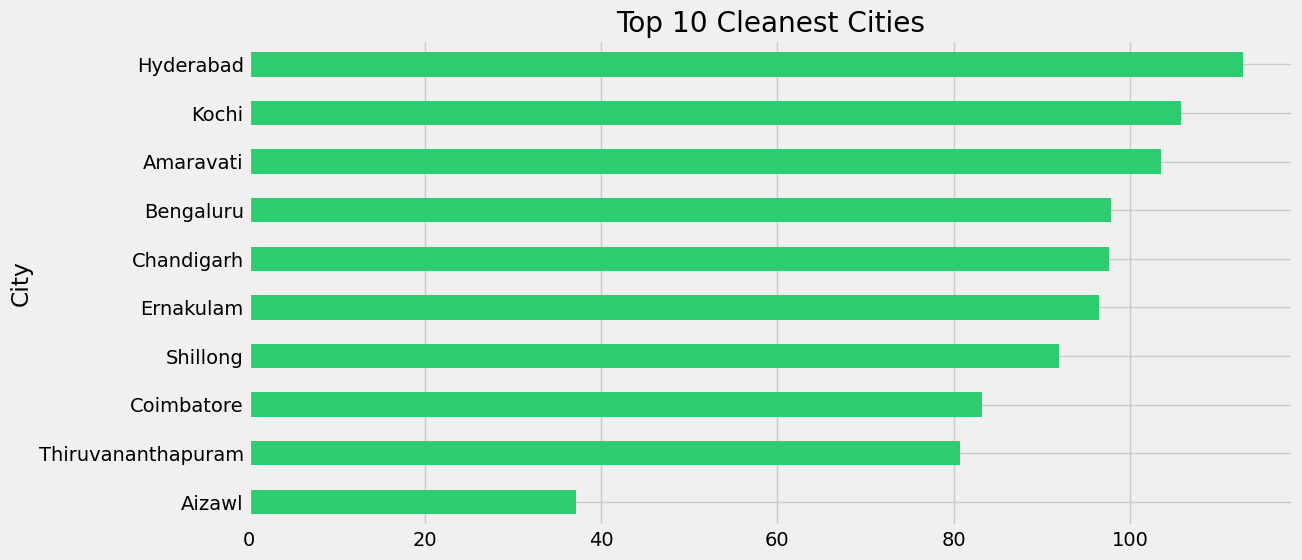

In [29]:
df.groupby("City")["AQI"].mean().nsmallest(10).plot(kind="barh", color="#2ecc71", title="Top 10 Cleanest Cities")

Text(0.5, 1.0, 'Average Pollutant Concentration Levels')

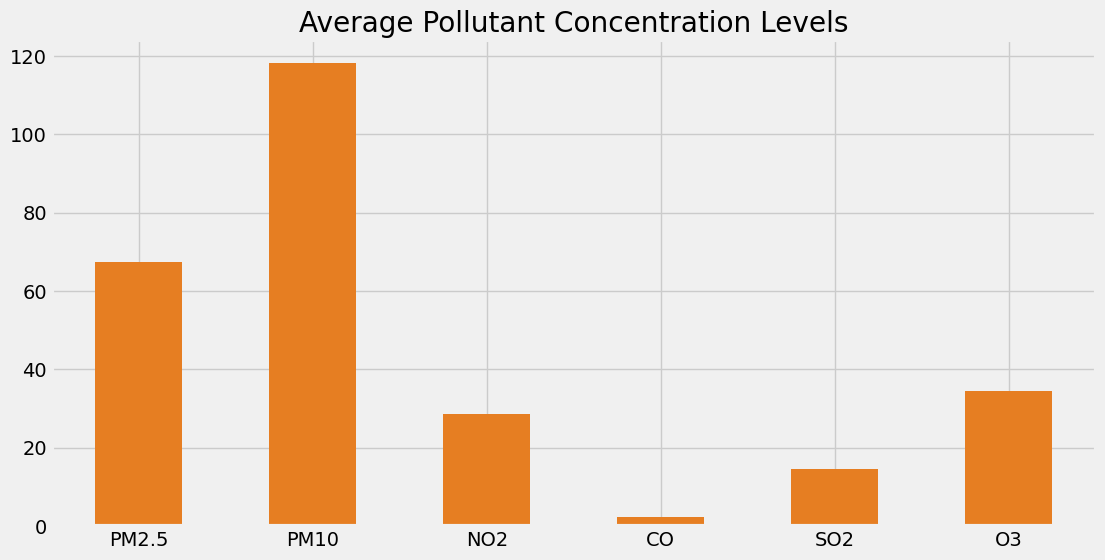

In [30]:
df[['PM2.5', 'PM10', 'NO2', 'CO', 'SO2', 'O3']].mean().plot(kind="bar", color="#e67e22", rot=0)
plt.title("Average Pollutant Concentration Levels")

Text(0.5, 1.0, 'Average AQI: Weekday vs Weekend')

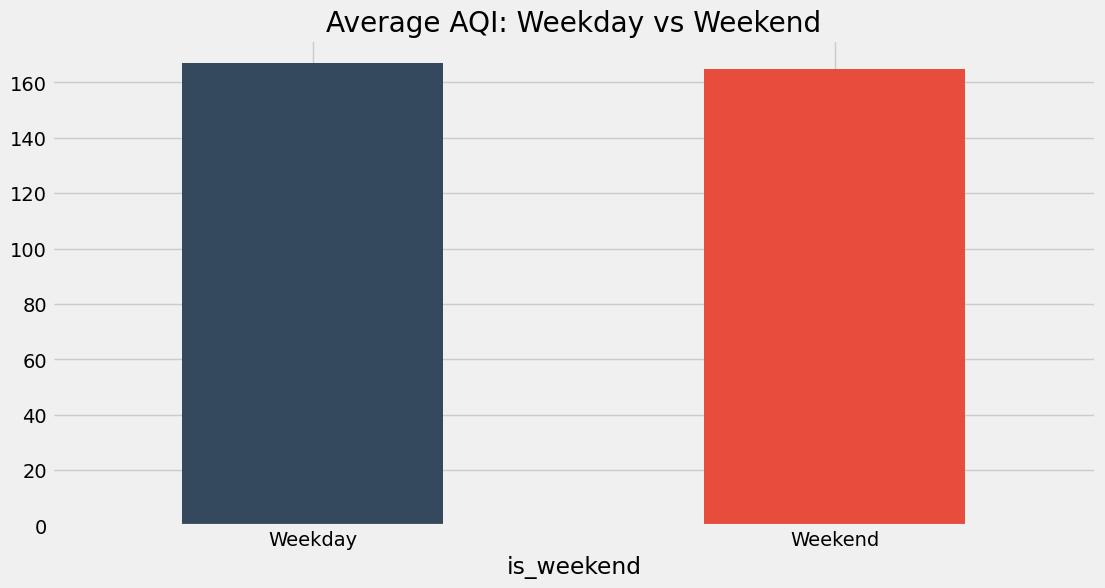

In [31]:
df['is_weekend'] = pd.to_datetime(df['Date']).dt.dayofweek >= 5
df.groupby('is_weekend')['AQI'].mean().plot(kind='bar', color=['#34495e', '#e74c3c'])
plt.xticks([0, 1], ['Weekday', 'Weekend'], rotation=0)
plt.title("Average AQI: Weekday vs Weekend")

Text(0.5, 1.0, 'Average AQI Across Seasons')

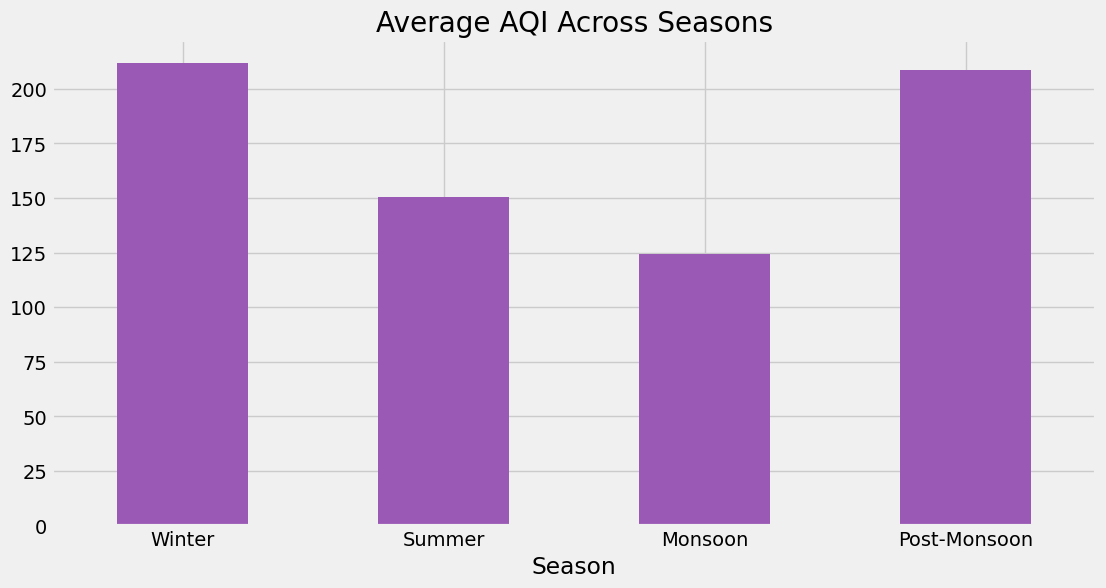

In [32]:
# Month
month_to_season = {12:'Winter', 1:'Winter', 2:'Winter', 3:'Summer', 4:'Summer', 5:'Summer', 6:'Monsoon', 7:'Monsoon', 8:'Monsoon', 9:'Monsoon', 10:'Post-Monsoon', 11:'Post-Monsoon'}
df['Season'] = pd.to_datetime(df['Date']).dt.month.map(month_to_season)

df.groupby('Season')['AQI'].mean().loc[['Winter', 'Summer', 'Monsoon', 'Post-Monsoon']].plot(kind='bar', color='#9b59b6', rot=0)
plt.title("Average AQI Across Seasons")

Unpacking multi-city air quality data reveals clear spatial and temporal patterns in India's environmental landscape. While most records hover within Moderate thresholds, industrial and high-density centers endure frequent toxic peaks. Atmospheric behavior follows a distinct seasonal beat—clearing during monsoon rains and worsening through winter atmospheric stagnation. Strong correlation matrices confirm that fine particulate matter (PM2.5 and PM10) dominates overall AQI scores. Ultimately, these insights highlight the urgency of real-time particulate tracking and targeted clean-air interventions in high-risk zones.